# <center> Homework 105

## Task 3

да се тества примера в книгата при който обучаваме модел който да разпознава всички обекти от fashion dataset-a без 2 (по избор), след което да се направи нов модел който да се дообучи да разпознава липсващите обекти.

In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

2026-01-12 13:03:01.134738: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-12 13:03:02.329647: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-12 13:03:06.888302: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [42]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

X_train_full, X_test = X_train_full / 255., X_test / 255.

In [24]:
ser = pd.Series(y_train_full)
ser.value_counts() / len(ser)

9    0.1
0    0.1
3    0.1
2    0.1
7    0.1
5    0.1
1    0.1
6    0.1
4    0.1
8    0.1
Name: count, dtype: float64

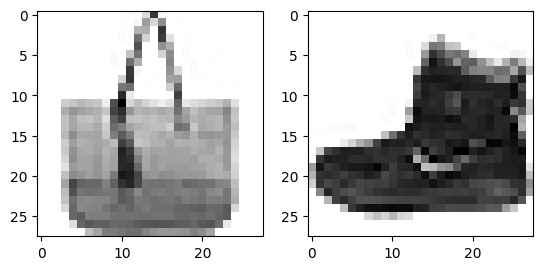

In [25]:
fig, ax = plt.subplots(1, 2)

ax[0].imshow(X_train_full[y_train_full == 8][1], cmap='binary')
ax[1].imshow(X_train_full[y_train_full == 9][0], cmap='binary')

In [43]:
A_train_mask = (y_train_full != 8) & (y_train_full != 9)
A_test_mask  = (y_test != 8) & (y_test != 9)

B_train_mask = ~A_train_mask
B_test_mask = ~A_test_mask

X_train_full_A, y_train_full_A = X_train_full[A_train_mask], y_train_full[A_train_mask]
X_train_full_B, y_train_full_B = X_train_full[B_train_mask], y_train_full[B_train_mask]
y_train_full_B = (y_train_full_B == 8).astype(int) 

X_test_A, y_test_A = X_test[A_test_mask], y_test[A_test_mask]
X_test_B, y_test_B = X_test[B_test_mask], y_test[B_test_mask]
y_test_B = (y_test_B == 8).astype(int)

X_train_A, y_train_A = X_train_full_A[:-5000], y_train_full_A[:-5000]
X_valid_A, y_valid_A = X_train_full_A[-5000:], y_train_full_A[-5000:]

X_train_B, y_train_B = X_train_full_B[:-5000], y_train_full_B[:-5000]
X_valid_B, y_valid_B = X_train_full_B[-5000:], y_train_full_B[-5000:]

In [27]:
model_A = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train_A.shape[1:]),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(8, activation='softmax'),
])

optimizer = tf.keras.optimizers.Adam()
model_A.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_A.fit(X_train_A, y_train_A, epochs=20, validation_data=(X_valid_A, y_valid_A))

Epoch 1/20


2026-01-09 16:08:53.839855: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 134848000 exceeds 10% of free system memory.


1344/1344 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8128 - loss: 0.5015 - val_accuracy: 0.8324 - val_loss: 0.4355
Epoch 2/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8520 - loss: 0.3913 - val_accuracy: 0.8334 - val_loss: 0.4299
Epoch 3/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8660 - loss: 0.3570 - val_accuracy: 0.8620 - val_loss: 0.3680
Epoch 4/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8734 - loss: 0.3350 - val_accuracy: 0.8562 - val_loss: 0.3685
Epoch 5/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8779 - loss: 0.3218 - val_accuracy: 0.8650 - val_loss: 0.3535
Epoch 6/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.8861 - loss: 0.3014 - val_accuracy: 0.8734 - val_loss: 0.3543
Epoch 7/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8895 - loss: 0.2908 - val_accuracy: 0.8720 - val_loss: 0.3425
Epoch 8/20
1344/1344 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.8944 - loss: 0.27

In [28]:
model_A.save('model_A.keras')

In [29]:
_, model_A_acc = model_A.evaluate(X_test_A, y_test_A)

 12/250 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8950 - loss: 0.4688

2026-01-09 16:14:50.845592: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 25088000 exceeds 10% of free system memory.


250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8759 - loss: 0.4018


In [ ]:
model_A = tf.keras.models.load_model('model_A.keras')
model_B = tf.keras.models.Sequential(model_A.layers[:-1]) 

In [32]:
model_A_clone = tf.keras.models.clone_model(model_A)
model_A_clone.set_weights(model_A.get_weights())

In [50]:
model_B.add(tf.keras.layers.Dense(1, activation='sigmoid'))

for layer in model_B.layers[:-1]:
    layer.trainable = False

In [51]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.001)
model_B.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
model_B.fit(X_train_B, y_train_B, epochs=5, validation_data=(X_valid_B, y_valid_B))

Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8957 - loss: 0.2860 - val_accuracy: 0.9548 - val_loss: 0.1568
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9696 - loss: 0.1289 - val_accuracy: 0.9774 - val_loss: 0.1058
Epoch 3/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9790 - loss: 0.0956 - val_accuracy: 0.9840 - val_loss: 0.0844
Epoch 4/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9831 - loss: 0.0792 - val_accuracy: 0.9868 - val_loss: 0.0722
Epoch 5/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9856 - loss: 0.0691 - val_accuracy: 0.9888 - val_loss: 0.0642


In [52]:
for layer in model_B.layers:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.0001)
model_B.compile(loss="binary_crossentropy", optimizer=optimizer, metrics=["accuracy"])
history = model_B.fit(X_train_B, y_train_B, epochs=15, validation_data=(X_valid_B, y_valid_B))

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9870 - loss: 0.0646 - val_accuracy: 0.9892 - val_loss: 0.0630
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9876 - loss: 0.0634 - val_accuracy: 0.9894 - val_loss: 0.0619
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9880 - loss: 0.0622 - val_accuracy: 0.9894 - val_loss: 0.0608
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9881 - loss: 0.0612 - val_accuracy: 0.9894 - val_loss: 0.0598
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9883 - loss: 0.0601 - val_accuracy: 0.9894 - val_loss: 0.0588
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9884 - loss: 0.0591 - val_accuracy: 0.9898 - val_loss: 0.0578
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9886 - loss: 0.0582 - val_accuracy: 0.9898 - val_loss: 0.0569
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9887 - loss: 0.0572 - val_accu

In [53]:
_, model_B_acc = model_B.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9900 - loss: 0.0580


In [56]:
model_B_without_transf = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train_B.shape[1:]),
    tf.keras.layers.Flatten(),
    
    tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

optimizer = tf.keras.optimizers.Adam()
model_B_without_transf.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model_B_without_transf.fit(X_train_B, y_train_B, epochs=20, validation_data=(X_valid_B, y_valid_B))

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.9914 - loss: 0.0252 - val_accuracy: 0.9988 - val_loss: 0.0038
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9979 - loss: 0.0073 - val_accuracy: 0.9978 - val_loss: 0.0066
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9984 - loss: 0.0056 - val_accuracy: 0.9990 - val_loss: 0.0034
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9987 - loss: 0.0032 - val_accuracy: 0.9986 - val_loss: 0.0067
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9989 - loss: 0.0049 - val_accuracy: 0.9970 - val_loss: 0.0137
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9978 - val_loss: 0.0101
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9999 - loss: 5.1156e-04 - val_accuracy: 0.9988 - val_loss: 0.0051
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9999 - loss: 6.0261e-04 - 

In [57]:
model_B_without_transf.evaluate(X_test_B, y_test_B)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9975 - loss: 0.0484


[0.04843653365969658, 0.9975000023841858]

## Task 4

да се обучи модел който да поправя дефектни изображеиня на цифрите от MNIST dataset-a

    да се изберат цифрите които се разпознават с най голяма сигурност
    да се обучи модел който при подадаена картинка да връща същата на изхода
    да се генерира dataset с дефектни изборажения, като се премахнат група точки от оригиналното изображение
    да се до-обучи модела като на входа се подава дефектното изображение, а на изхода същото без дефект
    да се тества модела с други дефектни изображения които не са участвали при тренирането


In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784')
X = mnist.data.values
y = mnist.target.to_numpy().astype(int)

In [59]:
model_helper = tf.keras.models.Sequential([
    tf.keras.layers.Input(X.shape[1:]),
    tf.keras.layers.Normalization(),

    tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(200, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(100, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam()
model_helper.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_helper.fit(X, y, epochs=20)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 24s 10ms/step - accuracy: 0.8810 - loss: 1.4337
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.9403 - loss: 0.2267
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9545 - loss: 0.1639
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9629 - loss: 0.1356
Epoch 5/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9674 - loss: 0.1202
Epoch 6/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9726 - loss: 0.1058
Epoch 7/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9754 - loss: 0.0923
Epoch 8/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9785 - loss: 0.0834
Epoch 9/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9811 - loss: 0.0814
Epoch 10/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - accuracy: 0.9827 - loss: 0.0716
Epoch 11/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.9828 - loss: 0.0744
Epoch 12/

In [85]:
model_helper.save('model_helper.keras')

In [4]:
model_helper = tf.keras.models.load_model('model_helper.keras')
probs = model_helper.predict(X)

2026-01-12 13:03:14.995521: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-01-12 13:03:17.737017: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 439040000 exceeds 10% of free system memory.


2188/2188 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step


In [5]:
confident_mask = probs.max(axis=1) > 0.9999999
confident_mask.sum()

np.int64(48315)

In [9]:
ser = pd.Series(y[confident_mask])
(ser.value_counts() / len(ser)) * 100

1    14.270930
0    13.523750
4    11.971437
7    11.404326
3    10.576426
5    10.061058
8     9.278692
2     7.916796
6     7.103384
9     3.893201
Name: count, dtype: float64

In [ ]:
X_confident, y_confident = X[confident_mask], y[confident_mask]

X_confident =  X_confident / 255.0

X_train_full_conf, X_test_conf = X_confident[:-5000], X_confident[-5000:]
y_train_full_conf, y_test_conf = y_confident[:-5000], y_confident[-5000:]

X_train_conf, X_valid_conf = X_train_full_conf[:-5000], X_train_full_conf[-5000:]
y_train_conf, y_valid_conf = y_train_full_conf[:-5000], y_train_full_conf[-5000:]

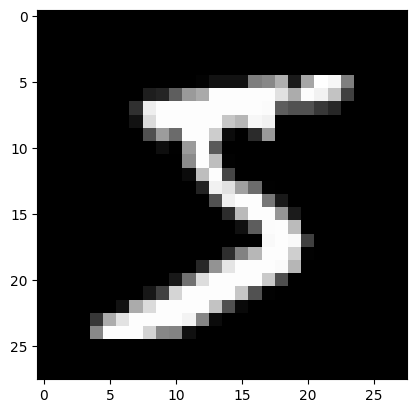

In [90]:
plt.imshow(X_confident[0].reshape(28, 28), cmap='gray')

In [91]:
model_main = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train_conf.shape[1:]),
    tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(300, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(X_train_conf.shape[-1])
])

optimizer = tf.keras.optimizers.Adam()
model_main.compile(optimizer=optimizer, loss='mse', metrics=['RootMeanSquaredError'])
model_main.fit(X_train_conf, X_train_conf, epochs=20, validation_data=(X_valid_conf, X_valid_conf))

Epoch 1/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - RootMeanSquaredError: 0.1343 - loss: 0.0180 - val_RootMeanSquaredError: 0.1001 - val_loss: 0.0100
Epoch 2/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - RootMeanSquaredError: 0.0928 - loss: 0.0086 - val_RootMeanSquaredError: 0.0881 - val_loss: 0.0078
Epoch 3/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - RootMeanSquaredError: 0.0853 - loss: 0.0073 - val_RootMeanSquaredError: 0.0836 - val_loss: 0.0070
Epoch 4/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - RootMeanSquaredError: 0.0815 - loss: 0.0066 - val_RootMeanSquaredError: 0.0803 - val_loss: 0.0064
Epoch 5/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - RootMeanSquaredError: 0.0791 - loss: 0.0063 - val_RootMeanSquaredError: 0.0786 - val_loss: 0.0062
Epoch 6/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - RootMeanSquaredError: 0.0774 - loss: 0.0060 - val_RootMeanSquaredError: 0.0766 - val_loss: 0.0059
Epoch 7/20
1198/1198 ━━━━━━━━━━━━━━━━━━━━ 22s 18ms/step - RootMe

In [93]:
model_main.save('model_main.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


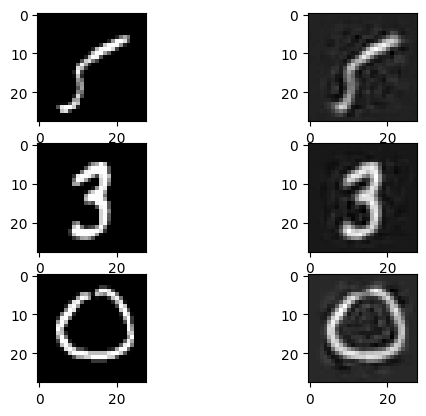

In [94]:
fig, ax = plt.subplots(3, 2)

img = X_test_conf[:3]
img_pred = model_main.predict(img)

for i in range(3):
    ax[i, 0].imshow(img[i].reshape(28, 28), cmap='gray')
    ax[i, 1].imshow(img_pred[i].reshape(28, 28), cmap='gray')


In [ ]:
# np.random.seed(42)

def make_defect_img(img, r = 8):
    img = img.reshape(28, 28).copy()

    x = np.random.randint(r, 29 - r)
    y = np.random.randint(r, 29 - r)

    img[x:x+r, y:y+r] = 0
    return img.ravel()

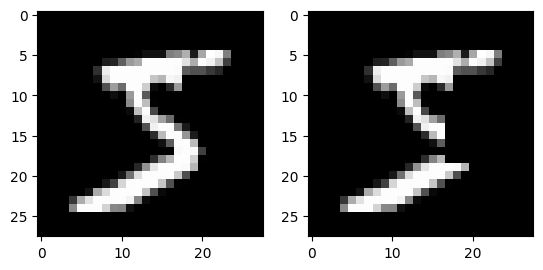

In [148]:
fig, ax = plt.subplots(1, 2)

img = X[0]

ax[0].imshow(img.reshape(28, 28), cmap='gray')
ax[1].imshow(make_defect_img(img).reshape(28, 28), cmap='gray')

In [150]:
N = 5_000
X_defect_conf = np.empty((N, X.shape[-1]))
inxs = np.random.permutation(X_confident.shape[0])[:N]

for i, inx in enumerate(inxs):
    X_defect_conf[i] = make_defect_img(X_confident[inx])

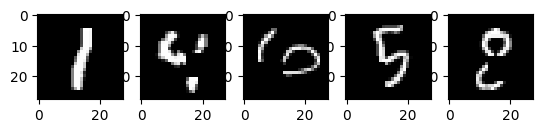

In [152]:
fig, ax = plt.subplots(1, 5)

for i in range(5):
    ax[i].imshow(X_defect_conf[i].reshape(28, 28), cmap='gray')

In [154]:
X_defect_train, X_defect_test = X_defect_conf[:-1000], X_defect_conf[-1000:]
train_inx, test_inx = inxs[:-1000], inxs[-1000:]

In [156]:
model_main.fit(X_defect_train, X_confident[train_inx], epochs=10)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - RootMeanSquaredError: 0.1351 - loss: 0.0182
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - RootMeanSquaredError: 0.1265 - loss: 0.0160
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - RootMeanSquaredError: 0.1227 - loss: 0.0151
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - RootMeanSquaredError: 0.1200 - loss: 0.0144
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - RootMeanSquaredError: 0.1179 - loss: 0.0139
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - RootMeanSquaredError: 0.1166 - loss: 0.0136
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - RootMeanSquaredError: 0.1157 - loss: 0.0134
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - RootMeanSquaredError: 0.1145 - loss: 0.0131
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - RootMeanSquaredError: 0.1137 - loss: 0.0129
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - RootMeanSquaredError: 0.1125 - loss: 0.0127


In [157]:
defect_img_pred = model_main.predict(X_defect_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


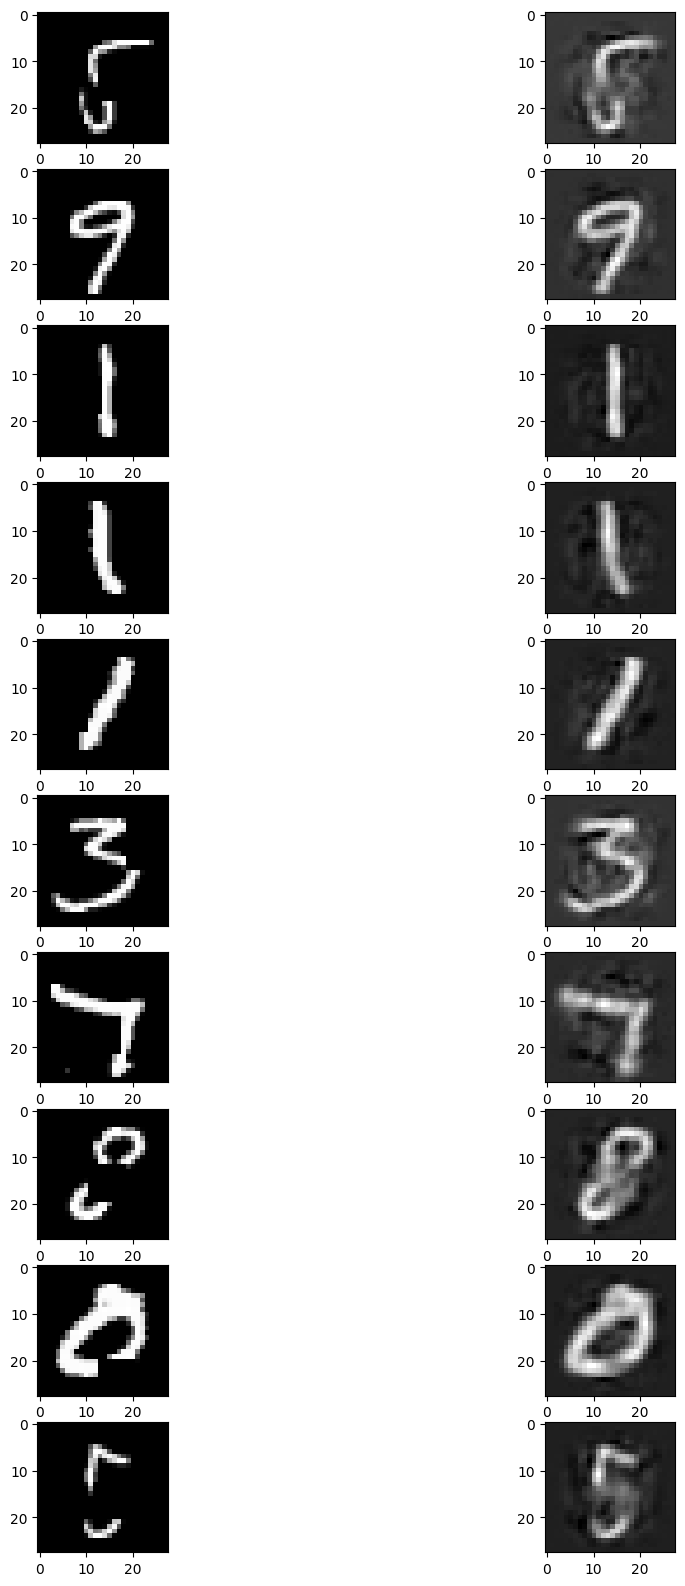

In [161]:
M = 10

fig, ax = plt.subplots(M, 2, figsize=(12, 20))

for i in range(M):
    ax[i, 0].imshow(X_defect_test[i].reshape(28, 28), cmap='gray')
    ax[i, 1].imshow(defect_img_pred[i].reshape(28, 28), cmap='gray')